In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/instagram_analytics.csv")

In [3]:
print(df.shape)
print(df.head())
print(df.info())

(29999, 23)
     post_id  account_id account_type  follower_count media_type  \
0  IG0000001           7        brand            3551       reel   
1  IG0000002          20      creator           31095      image   
2  IG0000003          15        brand            8167       reel   
3  IG0000004          11      creator            9044   carousel   
4  IG0000005           8      creator           15986       reel   

  content_category traffic_source  has_call_to_action        post_datetime  \
0       Technology      Home Feed                   1  2024-11-30 06:00:00   
1          Fitness       Hashtags                   1  2025-08-15 15:00:00   
2           Beauty     Reels Feed                   0  2025-09-11 16:00:00   
3            Music       External                   0  2025-09-18 03:00:00   
4       Technology        Profile                   0  2025-03-21 09:00:00   

    post_date  ...  comments shares  saves  reach  impressions  \
0  2024-11-30  ...         5      7     34  

In [4]:
df.isnull().sum()

post_id                     0
account_id                  0
account_type                0
follower_count              0
media_type                  0
content_category            0
traffic_source              0
has_call_to_action          0
post_datetime               0
post_date                   0
post_hour                   0
day_of_week                 0
likes                       0
comments                    0
shares                      0
saves                       0
reach                       0
impressions                 0
engagement_rate             0
followers_gained            0
caption_length              0
hashtags_count              0
performance_bucket_label    0
dtype: int64

In [5]:
missing_percent = (df.isnull().sum()/len(df))*100
print(missing_percent)

post_id                     0.0
account_id                  0.0
account_type                0.0
follower_count              0.0
media_type                  0.0
content_category            0.0
traffic_source              0.0
has_call_to_action          0.0
post_datetime               0.0
post_date                   0.0
post_hour                   0.0
day_of_week                 0.0
likes                       0.0
comments                    0.0
shares                      0.0
saves                       0.0
reach                       0.0
impressions                 0.0
engagement_rate             0.0
followers_gained            0.0
caption_length              0.0
hashtags_count              0.0
performance_bucket_label    0.0
dtype: float64


In [10]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [9]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  str    
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  str    
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  str    
 5   content_category          29999 non-null  str    
 6   traffic_source            29999 non-null  str    
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  str    
 9   post_date                 29999 non-null  str    
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  str    
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares           

In [20]:
df = df[df["follower_count"] >= 0]

In [21]:
df["post_date"] = pd.to_datetime(df["post_date"])

In [22]:
df = df[df["likes"] >= 0]

In [28]:
numerical_cols = [
    "follower_count",
    "likes",
    "comments",
    "shares",
    "reach",
    "impressions",
    "engagement_rate"
]

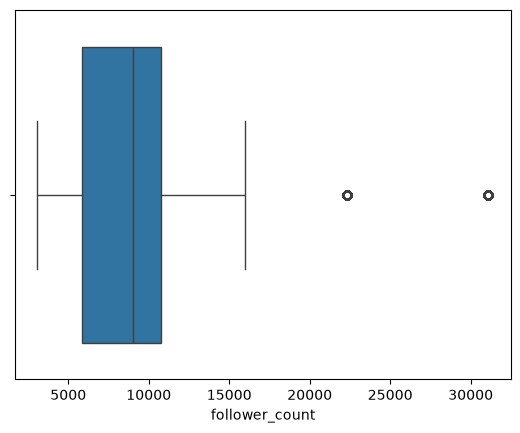

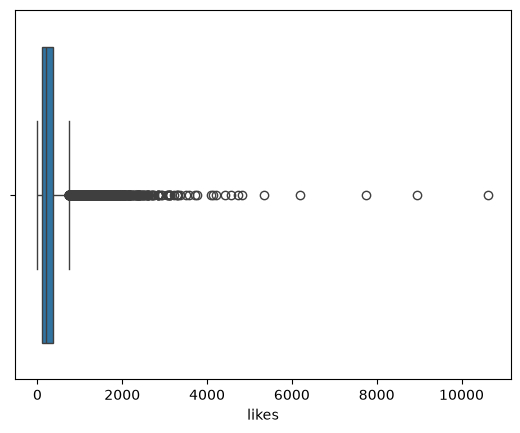

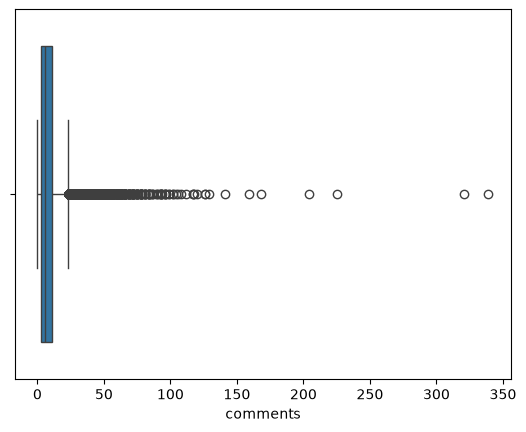

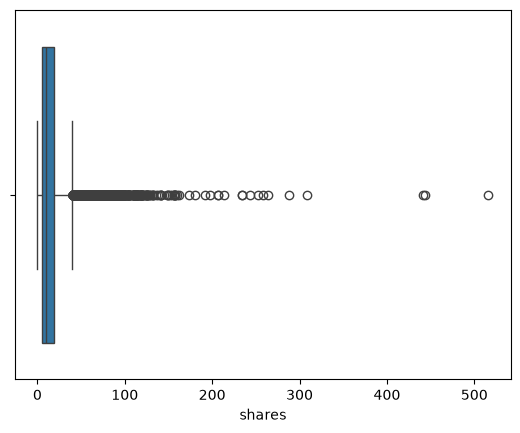

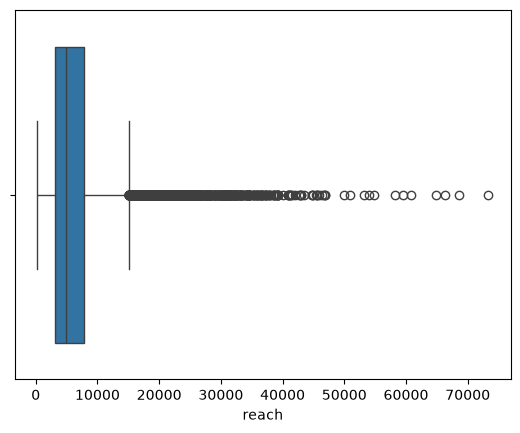

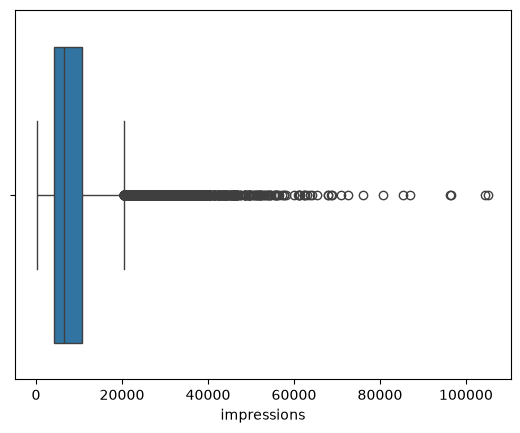

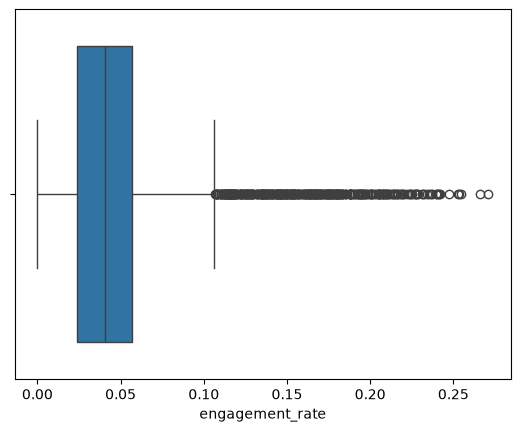

In [29]:
for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [30]:
def remove_outliers(df, column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[
        (df[column] >= lower) &
        (df[column] <= upper)
    ]

In [31]:
for col in numerical_cols:
    df = remove_outliers(df, col)

In [34]:
df["content_category"].unique()

<StringArray>
[ 'Technology',      'Beauty',       'Music', 'Photography',        'Food',
   'Lifestyle',      'Travel',     'Fashion',      'Comedy',     'Fitness']
Length: 10, dtype: str

In [36]:
df["content_category"] = df["content_category"].str.title()

In [37]:
print(df.shape)

print(df.info())

print(df.describe())

(23144, 23)
<class 'pandas.DataFrame'>
Index: 23144 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   post_id                   23144 non-null  str           
 1   account_id                23144 non-null  int64         
 2   account_type              23144 non-null  str           
 3   follower_count            23144 non-null  int64         
 4   media_type                23144 non-null  str           
 5   content_category          23144 non-null  str           
 6   traffic_source            23144 non-null  str           
 7   has_call_to_action        23144 non-null  int64         
 8   post_datetime             23144 non-null  str           
 9   post_date                 23144 non-null  datetime64[us]
 10  post_hour                 23144 non-null  int64         
 11  day_of_week               23144 non-null  str           
 12  likes                 

In [39]:
df.to_csv(
    "../data/cleaned/creator_cleaned.csv",
    index=False
)